In [ ]:
!pip install matplotlib numpy scikit-learn scikit-opt

: 

# Instalando Pacotes Necessários

In [116]:
import copy
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    precision_score,
    # roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sko.PSO import PSO
from dataclasses import dataclass
from time import time
import math



breast = load_breast_cancer()
x_breast = breast.data
y_breast = breast.target

wine = load_wine()
x_wine = wine.data
y_wine = wine.target

# Treinando o Breast MLP

In [86]:
x_breast_train, x_breast_test, y_breast_train, y_breast_test = train_test_split(
    x_breast, y_breast,
    test_size=0.3,
)
scaler = StandardScaler() # Faz estandartização -> média = 0 e variância = 1
scaler.fit(x_breast_train)

x_breast_train = scaler.transform(x_breast_train)
x_breast_test = scaler.transform(x_breast_test)

breast_n_feat = len(x_breast[0])

# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_net
# https://scikit-learn.org/stable/modules/neural_networks_supervised.html#classification Usa backprop
breast_mlp = MLPClassifier(
    hidden_layer_sizes=(breast_n_feat*5,1), # Extração de Características
    activation='logistic', # sigmoide
    solver='adam', # heurística de cálculo de gradiente como Adagrad/Nadam/etc...
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=5000,
    tol=1e-4,
    verbose=True,
    batch_size=len(x_breast_train) # fazer o cálculo do gradiente médio com todas as amostras
)
breast_mlp.fit(x_breast_train,y_breast_train)



Iteration 1, loss = 0.76455184
Iteration 2, loss = 0.75903552
Iteration 3, loss = 0.75374786
Iteration 4, loss = 0.74871009
Iteration 5, loss = 0.74393811
Iteration 6, loss = 0.73944239
Iteration 7, loss = 0.73522797
Iteration 8, loss = 0.73129465
Iteration 9, loss = 0.72763740
Iteration 10, loss = 0.72424689
Iteration 11, loss = 0.72111022
Iteration 12, loss = 0.71821162
Iteration 13, loss = 0.71553324
Iteration 14, loss = 0.71305584
Iteration 15, loss = 0.71075947
Iteration 16, loss = 0.70862404
Iteration 17, loss = 0.70662976
Iteration 18, loss = 0.70475757
Iteration 19, loss = 0.70298941
Iteration 20, loss = 0.70130836
Iteration 21, loss = 0.69969886
Iteration 22, loss = 0.69814667
Iteration 23, loss = 0.69663895
Iteration 24, loss = 0.69516420
Iteration 25, loss = 0.69371220
Iteration 26, loss = 0.69227400
Iteration 27, loss = 0.69084178
Iteration 28, loss = 0.68940882
Iteration 29, loss = 0.68796943
Iteration 30, loss = 0.68651885
Iteration 31, loss = 0.68505324
Iteration 32, los

,hidden_layer_sizes,"(150, ...)"
,activation,'logistic'
,solver,'adam'
,alpha,0.0001
,batch_size,398
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,5000
,shuffle,True
,random_state,None


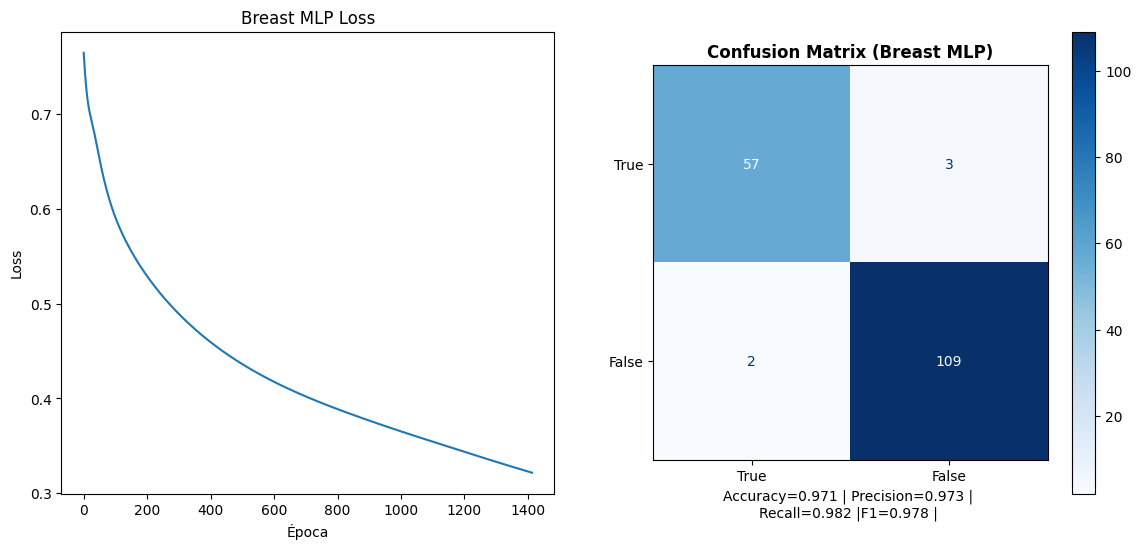

In [175]:
def test_classifier(
    ax,
    x_test : np.ndarray,
    y_test : np.ndarray,
    model,
    text: str,
    display_labels : list | None = ['True', 'False'],
    average: str | None = "binary"
) -> tuple[np.ndarray,list,list]:
    
    y_pred = model.predict(x_test)

    acuracia = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred,average=average)
    precision = precision_score(y_test, y_pred,average=average)
    f1 = f1_score(y_test, y_pred,average=average)
    # roc_auc = roc_auc_score(y_test,y_pred) # Professor não pediu
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(
        ax=ax,
        cmap='Blues',
        values_format='d',
        colorbar=True
    )
    ax.set_title(f'Confusion Matrix ({text})', fontsize=12, fontweight='bold')
    ax.set_ylabel("")
    ax.set_xlabel(
        f"Accuracy={acuracia:.3f} | "
        f"Precision={precision:.3f} | \n"
        f"Recall={recall:.3f} |"
        f"F1={f1:.3f} | "
        # f"ROC-AUC={roc_auc:.3f}" # Professor não pediu
    )

_, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(breast_mlp.loss_curve_)
ax[0].set_title("Breast MLP Loss")
ax[0].set_xlabel("Época")
ax[0].set_ylabel("Loss")
test_classifier(ax[1],x_breast_test,y_breast_test,breast_mlp,"Breast MLP")
plt.show()

# Treinando o WINE MLP

/home/rafael/comp_natural/trab2/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


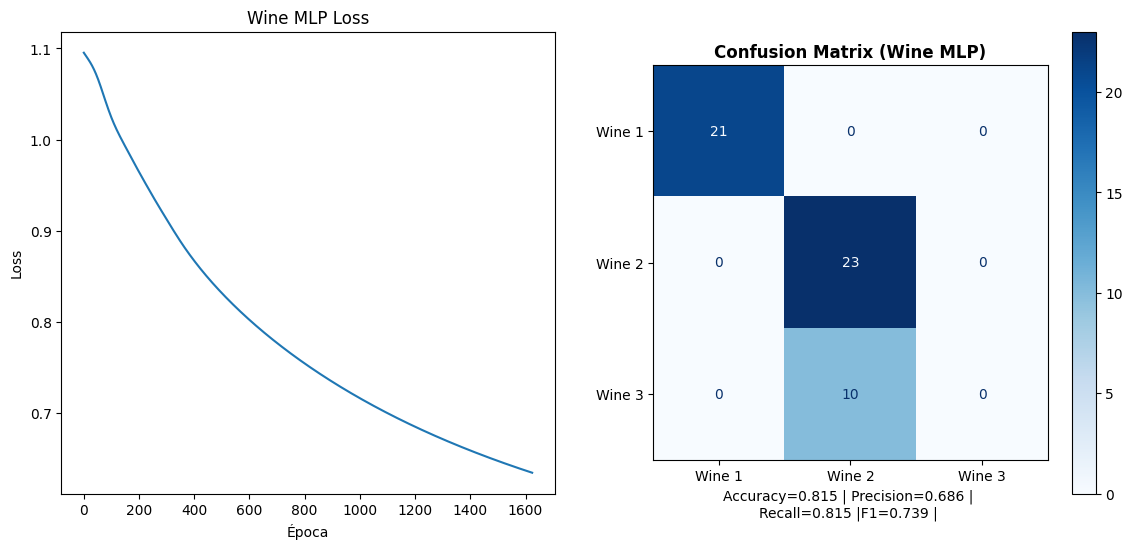

In [97]:
x_wine_train, x_wine_test, y_wine_train, y_wine_test = train_test_split(
    x_wine, y_wine,
    test_size=0.3,
)
scaler = StandardScaler()
scaler.fit(x_wine_train)

x_wine_train = scaler.transform(x_wine_train)
x_wine_test = scaler.transform(x_wine_test)

wine_n_feat = len(x_wine[0])

wine_mlp = MLPClassifier(
    hidden_layer_sizes=(wine_n_feat*5,1), # Extração de Características
    activation='logistic', # sigmoide
    solver='adam', # heurística de cálculo de gradiente como Adagrad/Nadam/etc...
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=5000,
    tol=1e-4,
    verbose=False, # Já foi visto como funciona, não necessita mais de ser verboso...
    batch_size=len(x_wine_train) # fazer o cálculo do gradiente médio com todas as amostras
)
wine_mlp.fit(x_wine_train,y_wine_train)

_, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(wine_mlp.loss_curve_)
ax[0].set_title("Wine MLP Loss")
ax[0].set_xlabel("Época")
ax[0].set_ylabel("Loss")
test_classifier(ax[1],x_wine_test,y_wine_test,wine_mlp,"Wine MLP",display_labels=["Wine 1","Wine 2","Wine 3"],average="weighted")
plt.show()

# Implementação da ELM

In [ ]:
# Não encontrei Libs, mas como é simples de implementar ...
class CustomELM:
    def __init__(self, discriminative_func, n_hidden : int | None = 10, W : np.ndarray | None = None):
        self.n_hidden = n_hidden
        self.W = W
        self.discriminative_func=discriminative_func

    def _sigmoid(self, x):
        x = np.clip(x, -50, 50) # evitar overflow
        return 1 / (1 + np.exp(-x))

    def fit(self, x, y, one_hot=False): # bias será imbutido em X
        x = np.hstack([x, np.ones((x.shape[0], 1))]) # Incializa um vetor de N_samples com valores 1, e coloca na direta do vetor inicial
        if self.W is None:
            self.W = np.random.randn(x.shape[1], self.n_hidden)
        
        if one_hot:
            y = to_one_hot(y)

        hidden_activation = self._sigmoid(x @ self.W) # Cálculo da camada intermediária
        self.hidden_W = np.linalg.pinv(hidden_activation) @ y # Cálculo da camada de saída (pseudoinversa)

    def predict(self, x):
        x = np.hstack([x, np.ones((x.shape[0], 1))])
        hidden_activation = self._sigmoid(x @ self.W)
        y = hidden_activation @ self.hidden_W
        y = self.discriminative_func(y) # Função discriminativa, para fazer a escolha da classe
        return y
    
    def score(self,x_test,y_test,average="binary"):
        y_pred = self.predict(x_test)
        # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score
        return f1_score(y_test, y_pred, average=average)

def binary_pred(
    y: np.ndarray,
) -> np.ndarray:
    return (y >= 0.5).astype(int) # Como no breast é binário

def one_hot_pred(
    y: np.ndarray,
) -> np.ndarray:
    softmax = []
    for y_array in y:
        den = 0
        score = []
        for y_val in y_array:
            y_val = np.clip(y_val, -50, 50) # evitar overflow
            den+=math.e**y_val
        for y_val in y_array:
            y_val = np.clip(y_val, -50, 50)
            score.append((math.e**y_val)/den)
        softmax.append(np.array(score))

    pred = []
    for score in softmax:
        pred.append(np.argmax(score)) 
    
    return np.array(pred)

def to_one_hot(
    y_array: np.ndarray
) -> None:
    n_classes = len(np.unique(y_array))
    y = np.eye(n_classes)[y_array] # transforma tudo para one-hot
    return y

def _fitness(weights,hidden_size,input_size,one_hot,discriminative_func,average,x_train,y_train,orthogonal_restriction=False):

    W = np.reshape(weights,(input_size,hidden_size))
    elm = CustomELM(W=W,discriminative_func=discriminative_func)
    elm.fit(x_train,y_train,one_hot)
    fitness = 1.0 - elm.score(x_train,y_train,average)
    if orthogonal_restriction:
        # https://numpy.org/doc/2.1/reference/generated/numpy.linalg.matrix_norm.html
        if hidden_size > input_size:
            fitness = fitness - np.linalg.matrix_norm(W @ W.T - np.eye(input_size),ord='fro')
        else:
            fitness = fitness - np.linalg.matrix_norm(W.T @ W - np.eye(hidden_size),ord='fro')

    return fitness # PSO minimiza a fitness, como o f1 varia de 0 a 1, basta substrair de um o score

# Breast ELM

Runtime = 28.593863248825073
Best Score Achieved : 1.0


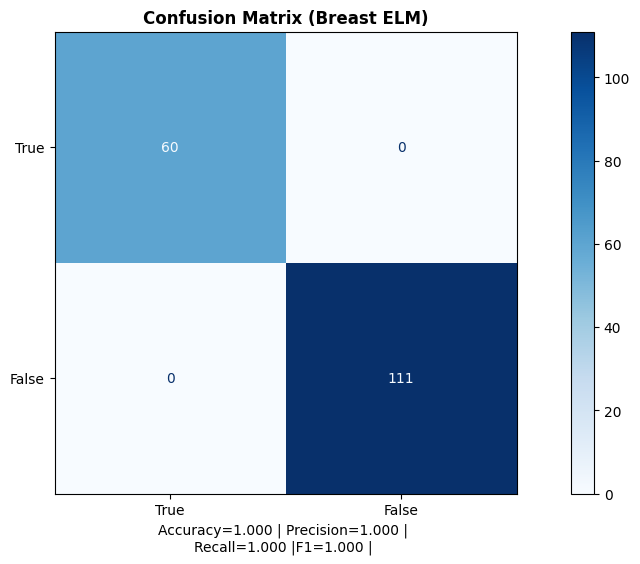

In [ ]:
N_PARTICLES=20 # Paper -> Entre 20-50
MAX_ITERATIONS=70

fitness_breast = partial(
    _fitness,
    hidden_size=int(x_breast.shape[1]*5),
    input_size=int(x_breast.shape[1]+1),
    one_hot=False,
    discriminative_func=binary_pred,
    average="binary",
    x_train=x_breast_train,
    y_train=y_breast_train,
)

particle_dimension = int( (x_breast.shape[1]*5) * (x_breast.shape[1]+1))
lb = -1e3 * np.ones(particle_dimension) # Virtualmente sem restrições
ub = 1e3 * np.ones(particle_dimension) # Virtualmente sem restrições

breast_pso = PSO(
    func=fitness_breast,
    n_dim=particle_dimension,
    pop=N_PARTICLES,
    max_iter=MAX_ITERATIONS,
    lb=lb,
    ub=ub,
    w=0.8, # w < 1
    c1=1.5, # c1 E [1,3]
    c2=1.5, # c2 E [1,3]
)

start_time = time()
breast_pso.run()
print(f"Runtime = {time()-start_time}")

best_weights = breast_pso.gbest_x
best_score = breast_pso.gbest_y.item()

print(f"Best Score Achieved : {1-best_score}")



# print(best_score)
# print(best_weights)
# print(1-best_score)

_, ax = plt.subplots(1, 1, figsize=(14, 6))
elm_breast = CustomELM(W=best_weights.reshape(x_breast.shape[1]+1,x_breast.shape[1]*5), discriminative_func=binary_pred)
elm_breast.fit(x_breast_train,y_breast_train)
test_classifier(ax,x_breast_test,y_breast_test,elm_breast,"Breast ELM", average="binary")


# Wine ELM

Runtime = 3.553903102874756
Best Score Achieved : 1.0


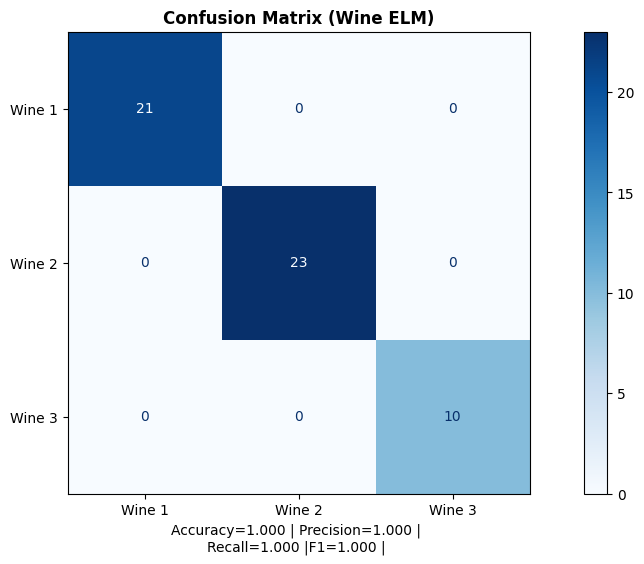

In [ ]:
particle_dimension = int( (x_wine.shape[1]*5) * (x_wine.shape[1]+1))
lb = -1e3 * np.ones(particle_dimension) # Virtualmente sem restrições
ub = 1e3 * np.ones(particle_dimension) # Virtualmente sem restrições
fitness_wine = partial(
    _fitness,
    hidden_size=int(x_wine.shape[1]*5),
    input_size=int(x_wine.shape[1]+1),
    one_hot=True,
    discriminative_func=one_hot_pred,
    average="weighted",
    x_train=x_wine_train,
    y_train=y_wine_train,
)
wine_pso = PSO(
    func=fitness_wine,
    n_dim=particle_dimension,
    pop=N_PARTICLES,
    max_iter=MAX_ITERATIONS,
    lb=lb,
    ub=ub,
    w=0.8, # w < 1
    c1=1.5, # c1 E [1,3]
    c2=1.5, # c2 E [1,3]
)

start_time = time()
wine_pso.run()
print(f"Runtime = {time()-start_time}")

best_weights = wine_pso.gbest_x
best_score = wine_pso.gbest_y.item()
print(f"Best Score Achieved : {1-best_score}")

_, ax = plt.subplots(1, 1, figsize=(14, 6))
elm_wine = CustomELM(W=best_weights.reshape(x_wine.shape[1]+1,x_wine.shape[1]*5), discriminative_func=one_hot_pred)
elm_wine.fit(x_wine_train,y_wine_train, one_hot=True)
test_classifier(ax,x_wine_test,y_wine_test,elm_wine,"Wine ELM",display_labels=["Wine 1","Wine 2","Wine 3"],average="weighted")

# Breast ELM com Restrição de Ortogonalidade

Runtime Orthogonal Restriction = 19.54807138442993
Best Score Achieved : 942517900.3736658


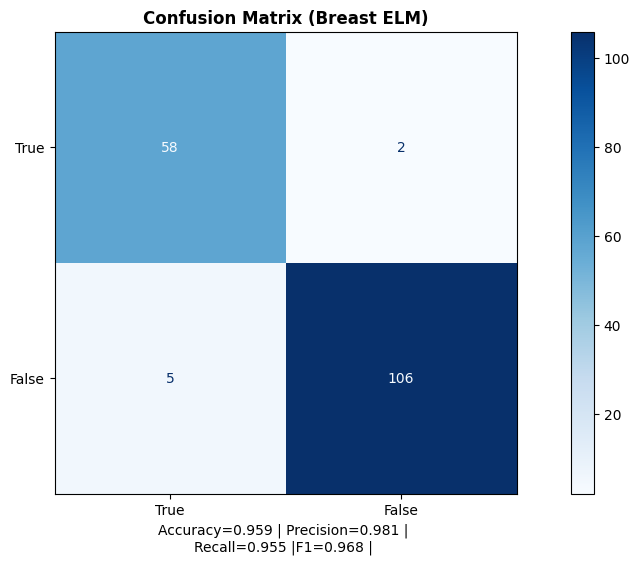

In [ ]:
fitness_breast = partial(
    _fitness,
    hidden_size=int(x_breast.shape[1]*5),
    input_size=int(x_breast.shape[1]+1),
    one_hot=False,
    discriminative_func=binary_pred,
    average="binary",
    x_train=x_breast_train,
    y_train=y_breast_train,
    orthogonal_restriction=True
)

particle_dimension = int( (x_breast.shape[1]*5) * (x_breast.shape[1]+1))
lb = -1e3 * np.ones(particle_dimension) # Virtualmente sem restrições
ub = 1e3 * np.ones(particle_dimension) # Virtualmente sem restrições

breast_pso = PSO(
    func=fitness_breast,
    n_dim=particle_dimension,
    pop=N_PARTICLES,
    max_iter=MAX_ITERATIONS,
    lb=lb,
    ub=ub,
    w=0.8, # w < 1
    c1=1.5, # c1 E [1,3]
    c2=1.5, # c2 E [1,3]
)

start_time = time()
breast_pso.run()
print(f"Runtime Orthogonal Restriction = {time()-start_time}")

best_weights = breast_pso.gbest_x
best_score = breast_pso.gbest_y.item()

print(f"Best Score Achieved : {1-best_score}")
_, ax = plt.subplots(1, 1, figsize=(14, 6))
elm_breast = CustomELM(W=best_weights.reshape(x_breast.shape[1]+1,x_breast.shape[1]*5), discriminative_func=binary_pred)
elm_breast.fit(x_breast_train,y_breast_train)
test_classifier(ax,x_breast_test,y_breast_test,elm_breast,"Breast ELM", average="binary")

# ELM Wine com Restrição de Ortogonalidade

Runtime Orthogonal Restriction = 4.65893030166626
Best Score Achieved : 277798485.7106091


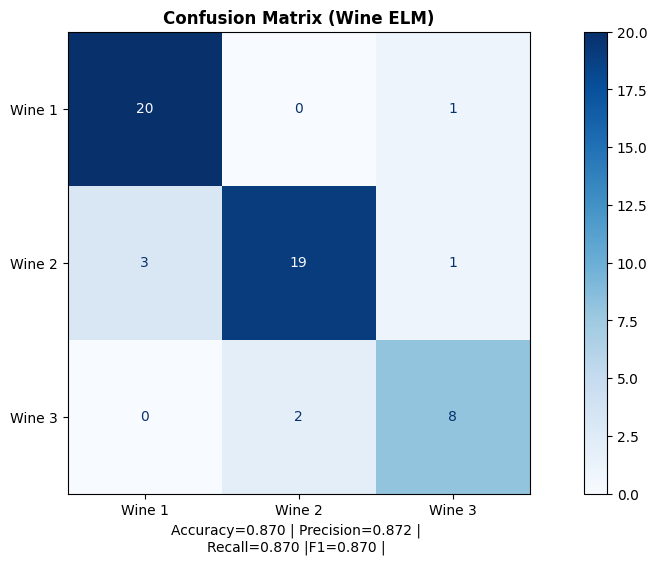

In [ ]:
particle_dimension = int( (x_wine.shape[1]*5) * (x_wine.shape[1]+1))
lb = -1e3 * np.ones(particle_dimension) # Virtualmente sem restrições
ub = 1e3 * np.ones(particle_dimension) # Virtualmente sem restrições
fitness_wine = partial(
    _fitness,
    hidden_size=int(x_wine.shape[1]*5),
    input_size=int(x_wine.shape[1]+1),
    one_hot=True,
    discriminative_func=one_hot_pred,
    average="weighted",
    x_train=x_wine_train,
    y_train=y_wine_train,
    orthogonal_restriction=True
)
wine_pso = PSO(
    func=fitness_wine,
    n_dim=particle_dimension,
    pop=N_PARTICLES,
    max_iter=MAX_ITERATIONS,
    lb=lb,
    ub=ub,
    w=0.8, # w < 1
    c1=1.5, # c1 E [1,3]
    c2=1.5, # c2 E [1,3]
)

start_time = time()
wine_pso.run()
print(f"Runtime Orthogonal Restriction = {time()-start_time}")

best_weights = wine_pso.gbest_x
best_score = wine_pso.gbest_y.item()
print(f"Best Score Achieved : {1-best_score}")

_, ax = plt.subplots(1, 1, figsize=(14, 6))
elm_wine = CustomELM(W=best_weights.reshape(x_wine.shape[1]+1,x_wine.shape[1]*5), discriminative_func=one_hot_pred)
elm_wine.fit(x_wine_train,y_wine_train, one_hot=True)
test_classifier(ax,x_wine_test,y_wine_test,elm_wine,"Wine ELM",display_labels=["Wine 1","Wine 2","Wine 3"],average="weighted")